# Spotify Tracks
# 1. Introduction and Objetives

## Problem Statement
The music industry relies heavily on intuition when predicting which tracks will succeed.
This project aims to explore whether audio features can help explain and predict track popularity.

## Objective
- Understand relationships between audio features and popularity
- Identify patterns across genres and time
- Prepare data for predictive modeling


Spotify Track - Key Questions
1. What audio features are most correlated with popularity?
2. Are popular tracks significantly different from unpopular ones?
3. Does genre influence popularity distribution?
4. Have audio characteristics changed over time?

# 2. Dataset Overview

Libraries and Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


df = pd.read_csv("../data/raw/SpotifyAudioFeaturesApril2019.csv")
df.head()


,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
0,YG,2RM4jf1Xa9zPgMGRDiht8O,"Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj",0.005820,0.743,238373,0.339,0.000,1,0.0812,-7.678,1,0.4090,203.927,4,0.118,15
1,YG,1tHDG53xJNGsItRA3vfVgs,BAND DRUM (feat. A$AP Rocky),0.024400,0.846,214800,0.557,0.000,8,0.2860,-7.259,1,0.4570,159.009,4,0.371,0
2,R3HAB,6Wosx2euFPMT14UXiWudMy,Radio Silence,0.025000,0.603,138913,0.723,0.000,9,0.0824,-5.890,0,0.0454,114.966,4,0.382,56
3,Chris Cooq,3J2Jpw61sO7l6Hc7qdYV91,Lactose,0.029400,0.800,125381,0.579,0.912,5,0.0994,-12.118,0,0.0701,123.003,4,0.641,0
4,Chris Cooq,2jbYvQCyPgX3CdmAzeVeuS,Same - Original mix,0.000035,0.783,124016,0.792,0.878,7,0.0332,-10.277,1,0.0661,120.047,4,0.928,0


In [6]:
df.info()
df.describe()
df.shape
df.columns
df.dtypes



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130663 entries, 0 to 130662
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artist_name       130663 non-null  object 
 1   track_id          130663 non-null  object 
 2   track_name        130662 non-null  object 
 3   acousticness      130663 non-null  float64
 4   danceability      130663 non-null  float64
 5   duration_ms       130663 non-null  int64  
 6   energy            130663 non-null  float64
 7   instrumentalness  130663 non-null  float64
 8   key               130663 non-null  int64  
 9   liveness          130663 non-null  float64
 10  loudness          130663 non-null  float64
 11  mode              130663 non-null  int64  
 12  speechiness       130663 non-null  float64
 13  tempo             130663 non-null  float64
 14  time_signature    130663 non-null  int64  
 15  valence           130663 non-null  float64
 16  popularity        13

artist_name          object
track_id             object
track_name           object
acousticness        float64
danceability        float64
duration_ms           int64
energy              float64
instrumentalness    float64
key                   int64
liveness            float64
loudness            float64
mode                  int64
speechiness         float64
tempo               float64
time_signature        int64
valence             float64
popularity            int64
dtype: object

The dataset contains 130,663 tracks and 17 features.
It includes a mix of categorical identifiers (artist_name, track_id, track_name)
and numerical audio features provided by Spotify.
Popularity is an integer variable ranging from 0 to 100 and will be treated as the target variable.


# 3. Data Quality Check

Identifiication Of Variables By Type

In [14]:
categorical_cols = ["artist_name", "track_id", "track_name"]
numerical_cols = df.columns.difference(categorical_cols)

categorical_cols, numerical_cols


(['artist_name', 'track_id', 'track_name'],
 Index(['acousticness', 'danceability', 'duration_ms', 'energy',
        'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'popularity',
        'speechiness', 'tempo', 'time_signature', 'valence'],
       dtype='object'))

Missing Values


In [15]:
df.isnull().sum().sort_values(ascending=False)


track_name          1
artist_name         0
track_id            0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
popularity          0
dtype: int64

The dataset contains 1 missing value on track_name (not significant)
This suggests that Spotify audio features are fully populated,
which simplifies preprocessing and model training.


Duplicated Values


In [16]:
df.duplicated().sum()


np.int64(0)

In [17]:
df["track_id"].duplicated().sum()


np.int64(337)

In [18]:
df[df["track_id"].duplicated(keep=False)].sort_values("track_id")


,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
121309,Clean Bandit,02mqJ3mpw8MLDmM2cqIVB9,Baby (feat. Marina & Luis Fonsi) - Luca Schrei...,0.28500,0.718,195147,0.735,0.000000,0,0.0545,-8.198,0,0.3530,122.969,4,0.336,55
94195,Clean Bandit,02mqJ3mpw8MLDmM2cqIVB9,Baby (feat. MARINA & Luis Fonsi) - Luca Schrei...,0.28500,0.718,195147,0.735,0.000000,0,0.0545,-8.198,0,0.3530,122.969,4,0.336,55
119258,Clean Bandit,02mqJ3mpw8MLDmM2cqIVB9,Baby (feat. Marina and The Diamonds & Luis Fon...,0.28500,0.718,195147,0.735,0.000000,0,0.0545,-8.198,0,0.3530,122.969,4,0.336,55
126535,Hillsong UNITED,03UNuZgtHViMboufVtawCa,Not Today,0.00236,0.580,253664,0.717,0.000014,2,0.1010,-8.014,1,0.0359,92.018,4,0.587,59
118079,Hillsong United,03UNuZgtHViMboufVtawCa,Not Today,0.00236,0.580,253664,0.717,0.000014,2,0.1010,-8.014,1,0.0359,92.018,4,0.587,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123961,A$AP Rocky,7ycWLEP1GsNjVvcjawXz3z,Praise The Lord (Da Shine),0.06090,0.850,205040,0.569,0.081600,5,0.1000,-8.152,0,0.1360,80.020,4,0.294,86
114143,Descemer Bueno,7yfha8TaN0DVNGp180Z5Zr,Nos Fuimos Lejos,0.16200,0.755,209360,0.880,0.000013,7,0.1320,-3.003,1,0.0605,94.022,4,0.812,60
130221,Descemer Bueno,7yfha8TaN0DVNGp180Z5Zr,Nos Fuimos Lejos (feat. El Micha),0.16200,0.755,209360,0.880,0.000013,7,0.1320,-3.003,1,0.0605,94.022,4,0.812,60
128933,Teqkoi,7zlGyAsvNMOdhTU068f79f,Please Come Back,0.51000,0.737,121522,0.241,0.005720,9,0.1080,-16.034,0,0.0882,100.000,4,0.345,63


Track IDs should be unique identifiers.
If duplicates are found, they may represent the same track appearing multiple times,
possibly due to different releases or metadata issues.
These cases will be handled during preprocessing.


Logical Ranges (Domain validation)

In [19]:
for col in [
    "acousticness", "danceability", "energy",
    "instrumentalness", "liveness", "speechiness", "valence"
]:
    print(col, df[(df[col] < 0) | (df[col] > 1)].shape[0])


acousticness 0
danceability 0
energy 0
instrumentalness 0
liveness 0
speechiness 0
valence 0


All continuous audio features fall within their expected [0,1] range,
indicating no apparent data corruption for these variables.


In [20]:
df[(df["popularity"] < 0) | (df["popularity"] > 100)].shape[0]


0

"popularity" fall within its expected [0,100] range, indicating no apparent data corruption for this variable


Numeric Outliers

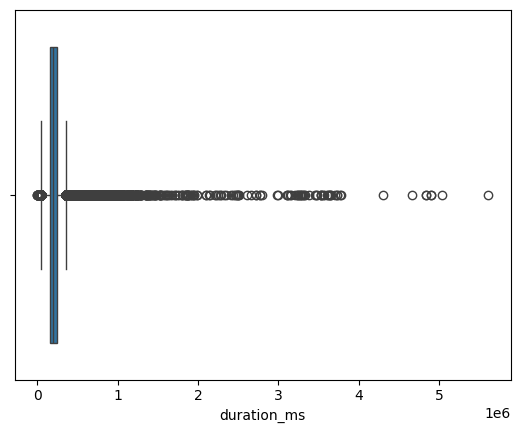

In [22]:
df["duration_ms"].describe()
sns.boxplot(x=df["duration_ms"])
plt.show()


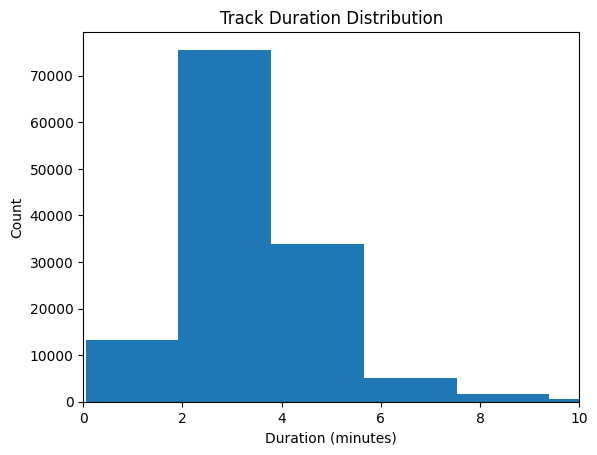

In [23]:
df['duration_min'] = df['duration_ms'] / 60000
plt.figure()
plt.hist(df['duration_min'], bins=50)
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.title("Track Duration Distribution")
plt.xlim(0, 10)
plt.show()


This plot comunicates in a better way the distribution and outliers present in this variable

Several extreme values are present, including very short and very long tracks.
These may correspond to interludes, ambient tracks, or metadata errors.



First, take a look at Popularity distribution


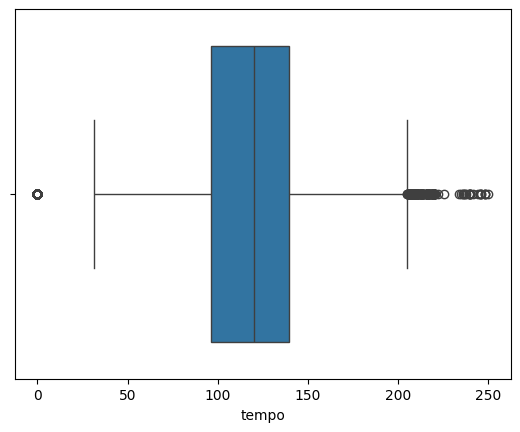

In [24]:
df["tempo"].describe()
sns.boxplot(x=df["tempo"])
plt.show()


Tempo presents extreme values that are unlikely for standard music tracks.
These values will be evaluated for capping or removal during preprocessing.


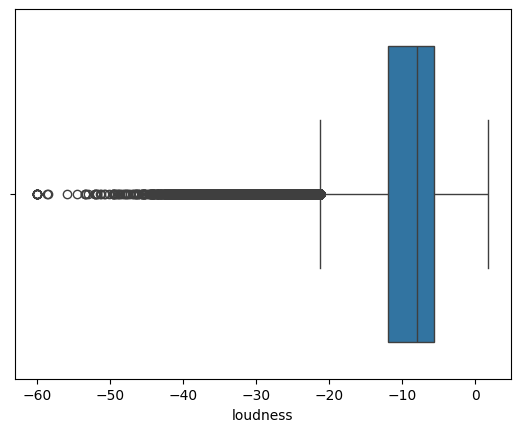

In [25]:
df["loudness"].describe()
sns.boxplot(x=df["loudness"])
plt.show()


Most of the track are located in the loudness war range, outliers may correspond to intros, outros, or experimental tracks

## Data Quality Summary

- 1 missing value was found in the dataset.
- Some duplicated track IDs are present and will be handled during preprocessing.
- All audio features respect their expected value ranges.
- Numerical features such as duration, tempo, and loudness contain extreme values,
  which may represent niche musical cases or errors.
- No records were removed at this stage to avoid premature data loss.


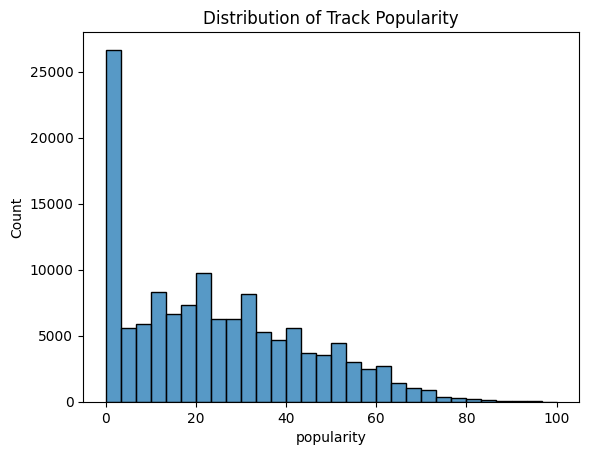

In [9]:
sns.histplot(df["popularity"], bins=30)
plt.title("Distribution of Track Popularity")
plt.show()


**Insight:** 
Since most songs have low popularity and only a few are very popular, predicting the exact value is not very informative. It is more useful and stable to predict popularity categories.

Popularity is skewed, with most tracks having low popularity and a small number achieving high popularity.
This suggests that classification may be more appropriate than regression.
Popularity:
It's a number (0–100)
It's NOT a continuous real number
It's a discrete score, constructed by Spotify
It depends on:
    streams
    recency
    internal (non-linear) algorithm

Even so, it's not an ideal variable for classical regression.

